Notes:
- The Phyisical model is inherently BIMODAL due to its bouncing nature, hence SigReg is forcing this to be unimodal 
- lambda being 0.05 yielded SigREG to be 5 at the end of 40 epochs 
- lambda baing 0.1 yielded better SigREG at minumum but more unstable training 
- Found VISReg (Wasserstein Distance), however this turns the problem from a Empereical Charecteristic Function (EC-Sketching) to an Optimal Transport Sketching Function 
- EMA -> SIGreg -> VISReg, Asymetry -> EC -> OT

In [1]:
import os 
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import copy, json, math
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from data import physics_process

from models import encoder, predictor
from SigReg import sigreg
from metrics import (effective_rank, rel_L1, embedding_std, moment_check,
                     action_sens, collect_emb, probe_r2)

In [2]:
# (Aug 17)
# need to add the action states
class BounceDataset(Dataset):
    def __init__(self, manifest_path, episode_ids, stack, k, n_roll=4):
        self.stack, self.k, self.n_roll = stack, k, n_roll
        manifest = json.load(open(manifest_path))

        self.frames, self.states, self.actions, self.physics = [], [], [], []
        self.index = []
        for entry in manifest:
            if entry["seed"] not in episode_ids:
                continue
            d = np.load(entry["path"])
            f, s, a = d["frames"], d["states"], d["actions"]
            slot = len(self.frames)
            self.frames.append(f)
            self.states.append(s)
            self.actions.append(a)
            self.physics.append(np.array([entry["bounce"], entry["friction"]], dtype=np.float32))

            T = d["frames"].shape[0]
            for t in range(T - stack - n_roll * k + 1):
                self.index.append((slot, t))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        slot, t = self.index[i]
        f, s, a = self.frames[slot], self.states[slot], self.actions[slot]

        ctx = f[t : t + self.stack]
        tgts = np.stack([f[t + n*self.k : t + n*self.k + self.stack]
                         for n in range(1, self.n_roll + 1)])
        raw = a[t + self.stack - 1 : t + self.stack - 1 + self.n_roll]
        acts = (raw[:, 0] + 2) * 5 + (raw[:, 1] + 2)

        ctx  = torch.from_numpy(ctx.astype(np.float32) / 255.0)
        tgts = torch.from_numpy(tgts.astype(np.float32) / 255.0)
        acts = torch.from_numpy(acts.astype(np.int64))
        state = torch.from_numpy(s[t + self.stack - 1])
        physics = torch.from_numpy(self.physics[slot])
        return ctx, tgts, acts, state, physics

In [3]:
import json, os
os.makedirs("episodes", exist_ok=True)
manifest = []
N_EPISODES = 500 
for ep in range(N_EPISODES):
    rng = np.random.default_rng(ep)          #
    r  = rng.uniform(3, 8)
    x  = rng.uniform(r, 64 - r)
    y  = rng.uniform(r, 64 - r)
    vx = rng.uniform(-5, 5)
    vy = rng.uniform(-5, 5)
    hold = int(rng.integers(2, 8))
    bounce = rng.uniform(0.5, 1.0)
    friction = rng.uniform(0.1, 0.9)
    frames, states, actions = physics_process(x, y, vx, vy, rng, r=r, offset=2, bounce=bounce, friction=friction,hold=int(hold), frames=120, dt=0.05)
    path = f"episodes/ep_{ep:04d}.npz"
    np.savez_compressed(path, frames=frames, states=states, actions=actions,
                        radius=r, bounce=bounce,
                        friction=friction, hold=hold, dt=0.05, seed=ep)
    manifest.append({"path": path, "radius": float(r), "bounce": float(bounce),
                     "friction": float(friction), "hold": hold, "seed": ep})

json.dump(manifest, open("episodes/manifest.json", "w"), indent=2)


In [4]:
# A bit more organized this time
STACK, K_STRIDE, N_ROLL = 8, 2, 4
EPOCHS, BS, LR, WD = 80, 256, 1e-4, 0.05
LAMBDA, N_ACTIONS = 0.1, 25
DEV = "cuda"



In [ ]:
manifest = json.load(open("episodes/manifest.json"))
seeds = np.array([e["seed"] for e in manifest])
np.random.default_rng(0).shuffle(seeds)
n_val = int(0.15 * len(seeds))
val_id  = set(seeds[:n_val].tolist())
train_id = set(seeds[n_val:].tolist())

train_ds = BounceDataset("episodes/manifest.json", train_id, STACK, K_STRIDE, n_roll=N_ROLL)
val_ds   = BounceDataset("episodes/manifest.json", val_id,   STACK, K_STRIDE, n_roll=N_ROLL)
train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True, drop_last=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BS, shuffle=False)

m_ctx, m_tgts, m_acts, m_state, m_phys = next(iter(val_loader))
m_ctx, m_tgts, m_acts = m_ctx.to(DEV), m_tgts.to(DEV), m_acts.to(DEV)

In [6]:
enc = encoder(in_channels=STACK).to(DEV)
pred_net = predictor(latent=128, n_actions=N_ACTIONS).to(DEV)

opt = torch.optim.AdamW(list(enc.parameters()) + list(pred_net.parameters()),
                        lr=LR, weight_decay=WD)

In [ ]:

print(pred_net.action_embedding.num_embeddings)     
a_check = next(iter(train_loader))[2]
print(a_check.min().item(), a_check.max().item())    
step = 0
history, best_pred = [], float("inf")
for epoch in range(EPOCHS):
    enc.train(); pred_net.train()
    for ctx, tgts, acts, _, _ in train_loader:
        ctx, tgts, acts = ctx.to(DEV), tgts.to(DEV), acts.to(DEV)

        z = enc(ctx)
        z_ctx, z_tgts = z, []
        loss_pred = 0.0
        for n in range(N_ROLL):
            z = pred_net(z, acts[:, n])
            zt = enc(tgts[:, n])                    # same encoder, grads flow
            z_tgts.append(zt)
            loss_pred = loss_pred + F.l1_loss(z, zt)
        loss_pred = loss_pred / N_ROLL

        loss_sig = sigreg(torch.cat([z_ctx] + z_tgts), step)
        loss = loss_pred + LAMBDA * loss_sig

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(enc.parameters()) + list(pred_net.parameters()), 1.0)
        opt.step()
        step += 1
    enc.eval(); pred_net.eval()
    with torch.no_grad():
        z0 = enc(m_ctx)
        z = z0
        roll, ident = [], []
        for n in range(N_ROLL):
            z = pred_net(z, m_acts[:, n])
            zt = enc(m_tgts[:, n])
            roll.append(rel_L1(z, zt))
            ident.append(rel_L1(z0, zt))
        mom = moment_check(z0)
        horiz = "  ".join(f"n{n+1} {r:.3f}/{i:.3f}" for n, (r, i) in enumerate(zip(roll, ident)))
        print(f"ep {epoch:3d} | pred {loss_pred.item():.4f} | sig {loss_sig.item():.3f} | {horiz}"
              f" | erank {effective_rank(z0):.1f} | mean {mom['mean_norm']:.3f}"
              f" | std {mom['std_mean']:.2f} [{mom['std_min']:.2f}-{mom['std_max']:.2f}]")
    history.append({"epoch": epoch, "pred": loss_pred.item(), "sig": loss_sig.item(),
                    "erank": float(effective_rank(z0)), "mean_norm": mom["mean_norm"],
                    "roll": [float(r) for r in roll]})

    if loss_pred.item() < best_pred:
        best_pred = loss_pred.item()
        torch.save({
        "enc": enc.state_dict(),
        "pred": pred_net.state_dict(),
        "opt": opt.state_dict(),
        "epoch": epoch,
        "step": step,
        "history": history or [],
        "config": {
            "stack": STACK, "k": K_STRIDE, "n_roll": N_ROLL,
            "latent": 128, "n_actions": 25, "n_dim": 48, "hidden": 1024,
            "lambda": LAMBDA, "lr": LR, "wd": WD,
            "regularizer": "sigreg_ep",          # arm label for the comparison
            "sigreg": {"num_slices": 256, "t_points": 25, "t_range": [-5, 5]},
        },
    }, 'checkpoint/lewm_best.pt')
    if epoch in (0, 5):
        with torch.no_grad():
            print(f"    action_sensitivity: {action_sens(pred_net, enc(m_ctx)):.4f}")
    if epoch % 10 == 0:
        Z, Y = collect_emb(enc, val_ds)
        print("   ", {k: v["linear"] for k, v in probe_r2(Z, Y).items()})

25
0 24
ep   0 | pred 0.4637 | sig 12.620 | n1 0.458/0.255  n2 0.568/0.459  n3 0.644/0.619  n4 0.700/0.742 | erank 19.6 | mean 3.156 | std 0.99 [0.49-1.85]
    action_sensitivity: 0.0511
ep   1 | pred 0.4583 | sig 10.103 | n1 0.453/0.270  n2 0.568/0.483  n3 0.646/0.647  n4 0.703/0.769 | erank 21.4 | mean 3.063 | std 1.01 [0.61-1.77]
ep   2 | pred 0.4567 | sig 9.004 | n1 0.427/0.277  n2 0.539/0.495  n3 0.617/0.661  n4 0.677/0.783 | erank 22.8 | mean 3.150 | std 1.03 [0.61-1.63]
ep   3 | pred 0.4304 | sig 8.584 | n1 0.410/0.280  n2 0.513/0.498  n3 0.582/0.662  n4 0.641/0.782 | erank 23.8 | mean 3.133 | std 1.02 [0.63-1.58]
ep   4 | pred 0.3997 | sig 8.980 | n1 0.393/0.284  n2 0.497/0.507  n3 0.564/0.673  n4 0.623/0.794 | erank 24.5 | mean 3.056 | std 1.03 [0.62-1.66]
ep   5 | pred 0.3944 | sig 8.377 | n1 0.376/0.291  n2 0.477/0.519  n3 0.541/0.687  n4 0.598/0.808 | erank 25.5 | mean 2.965 | std 1.02 [0.59-1.61]
    action_sensitivity: 0.0533
ep   6 | pred 0.3569 | sig 7.923 | n1 0.357/0.

In [8]:
# Find the most active dims when it comes to descision making, its not that evenly disrtubited 
enc.eval()
with torch.no_grad():
    Z = enc(m_ctx)                      
    mu = Z.mean(0)                      # [128]
    print("norm:", mu.norm().item())
    top = mu.abs().topk(30)
    print("top dims:", top.indices.tolist())
    print("top vals:", [f"{v:.2f}" for v in mu[top.indices].tolist()])
    print("median |mean|:", mu.abs().median().item())
    print(sigreg(Z, 0).item(), sigreg(Z - Z.mean(0), 0).item())

norm: 1.8505771160125732
top dims: [72, 0, 79, 52, 45, 64, 47, 7, 114, 58, 13, 110, 123, 63, 69, 100, 77, 105, 118, 49, 8, 61, 87, 46, 20, 12, 109, 36, 6, 24]
top vals: ['0.52', '0.37', '-0.37', '0.36', '-0.36', '0.35', '-0.35', '-0.34', '0.34', '0.34', '0.30', '0.29', '0.27', '0.26', '0.26', '-0.25', '0.24', '-0.24', '-0.23', '-0.23', '0.23', '-0.22', '-0.21', '-0.21', '-0.21', '-0.20', '-0.20', '0.20', '0.20', '-0.20']
median |mean|: 0.10667695105075836
14.236283302307129 5.829743385314941


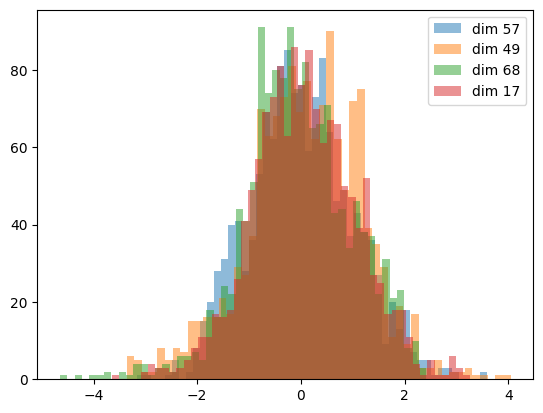

In [ ]:
# Check the Unimodality and Gaussianness of the most activated dims
import matplotlib.pyplot as plt
for d in [57, 49, 68, 17]:
    plt.hist(Z[:, d].cpu().numpy(), bins=50, alpha=0.5, label=f"dim {d}")
plt.legend(); plt.show()

246 / 1400


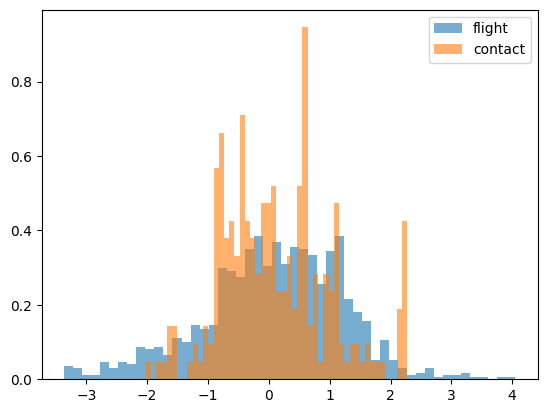

In [17]:
import numpy as np, torch, json, matplotlib.pyplot as plt

manifest = json.load(open("episodes/manifest.json"))
val_entries = [e for e in manifest if e["seed"] in val_id]

Zs, masks = [], []
enc.eval()
with torch.no_grad():
    for slot, e in enumerate(val_entries[:50]):
        d = np.load(e["path"])
        f, s, r = d["frames"], d["states"], e["radius"]
        contact = s[:, 1] + r >= 63 - 1e-3
        for t in range(0, f.shape[0] - 8, 4):
            ctx = torch.from_numpy(f[t:t+8].astype(np.float32)/255.).unsqueeze(0).cuda()
            Zs.append(enc(ctx).cpu())
            masks.append(contact[t:t+8].any())

Z, m = torch.cat(Zs), np.array(masks)
print(m.sum(), "/", len(m))
plt.hist(Z[~m, 49].numpy(), bins=50, alpha=.6, density=True, label="flight")
plt.hist(Z[m, 49].numpy(), bins=50, alpha=.6, density=True, label="contact")
plt.legend(); plt.show()

In [8]:
ds = BounceDataset("episodes/manifest.json", set(range(500)), 8, 2, 4)
lo, hi = 100, -1
for i in range(0, len(ds), 997):        
    a = ds[i][2]
    lo, hi = min(lo, a.min().item()), max(hi, a.max().item())
print(lo, hi)     # must be within [0, n_actions-1]

0 24
